# T10 VAR -- 货币政策传导机制

## 0. 论文信息

| 字段 | 内容 |
|------|------|
| **论文题目** | 人民币汇率的价格传递效应——基于VAR模型的实证分析 |
| **作者** | 陈六傅, 刘厚俊 |
| **期刊** | 《经济研究》(7), 52-64, 2008 |
| **核心问题** | 货币供给冲击如何传导至CPI和GDP？传导时滞如何？ |
| **方法** | VAR(p) + OIRF(Cholesky) + FEVD + Granger因果 |

## 1. 研究设计

货币政策传导：M2 -> 利率r -> 投资消费 -> GDP/CPI

Cholesky排序: M2 -> r -> CPI -> GDP
(货币供给当期不受其他变量即时影响)

## 2. 数学理论

**VAR(p)**:
$$\mathbf{y}_t = \mathbf{c} + \sum_{l=1}^p \mathbf{A}_l \mathbf{y}_{t-l} + \boldsymbol{\varepsilon}_t$$

**OIRF**: Cholesky分解 $\boldsymbol{\Sigma}=\mathbf{PP}^\top$，IRF shape: (h+1, K, K)
其中 irf[h, response_var, impulse_var]

**稳定性**: 伴随矩阵特征根模 < 1

## 3. 数据加载与预处理

In [1]:
import sys, io, re as _re
from pathlib import Path

def _add_repo_to_path():
    try:
        nb_file = Path(__vsc_ipynb_file__)   # noqa: F821
    except NameError:
        nb_file = Path.cwd() / '_dummy.ipynb'
    for p in [nb_file.parent, *nb_file.parents]:
        if (p / 'empirlab').is_dir() and (p / 'setup.py').exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return p
    return None

_add_repo_to_path()

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm

_CJK_RE = _re.compile(
    r'[\u4e00-\u9fff\u3000-\u303f\uff00-\uffef\u2e80-\u2eff\u3400-\u4dbf]')

def _set_cjk_font():
    available = {f.name for f in _fm.fontManager.ttflist}
    for _f in ['Microsoft YaHei','SimHei','SimSun','PingFang SC',
               'Heiti SC','STHeiti','Arial Unicode MS']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'full'
    for _f in ['WenQuanYi Micro Hei','Noto Sans CJK SC','Droid Sans Fallback']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'cjk_only'
    matplotlib.rcParams['axes.unicode_minus'] = False
    return 'none'

_FONT_MODE = _set_cjk_font()

def _fix_all_text(fig):
    """Fix every text element: pure-Latin→DejaVu, CJK→Droid, mixed→split."""
    def fix(t):
        txt = t.get_text()
        if not txt:
            return
        if _CJK_RE.search(txt):
            # Contains CJK — keep Droid for Chinese glyphs
            # But also handle Latin parts by rendering mixed via two passes
            t.set_fontfamily('Droid Sans Fallback')
        else:
            # Pure Latin/digits/ASCII — DejaVu renders correctly
            t.set_fontfamily('DejaVu Sans')

    for ax in fig.get_axes():
        fix(ax.title)
        fix(ax.xaxis.label)
        fix(ax.yaxis.label)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            fix(lbl)
        for txt in ax.texts:
            fix(txt)
        leg = ax.get_legend()
        if leg:
            for t in leg.get_texts():
                fix(t)
    if hasattr(fig, '_suptitle') and fig._suptitle:
        fix(fig._suptitle)

def show(fig=None):
    """Embed figure as PNG (works in VS Code, JupyterLab, nbconvert, GitHub)."""
    from IPython.display import display, Image
    fig = fig or plt.gcf()
    if _FONT_MODE == 'cjk_only':
        _fix_all_text(fig)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

from empirlab.traditional.var import VAR, macro_data

df = macro_data()
print("列名:", list(df.columns))
print(df.describe().round(3))
df.head()


列名: ['date', 'lnm2', 'lncpi', 'lnrgdp', 'r']
                      date     lnm2    lncpi   lnrgdp        r
count                  120  120.000  120.000  120.000  120.000
mean   2014-11-15 16:48:00   11.625    8.466    8.889    0.040
min    2000-01-01 00:00:00   10.145    7.508    7.962   -0.248
25%    2007-06-08 06:00:00   10.904    8.009    8.452   -0.100
50%    2014-11-16 00:00:00   11.660    8.465    8.914    0.046
75%    2022-04-23 18:00:00   12.308    8.898    9.346    0.173
max    2029-10-01 00:00:00   13.019    9.352    9.850    0.319
std                    NaN    0.833    0.530    0.518    0.159


,date,lnm2,lncpi,lnrgdp,r
0,2000-01-01,10.144684,7.508331,8.015236,-0.248089
1,2000-04-01,10.213957,7.568417,7.963001,-0.227384
2,2000-07-01,10.276209,7.528554,8.067523,-0.236260
3,2000-10-01,10.372363,7.577027,8.092028,-0.232010
4,2001-01-01,10.307086,7.709296,7.962448,-0.187662


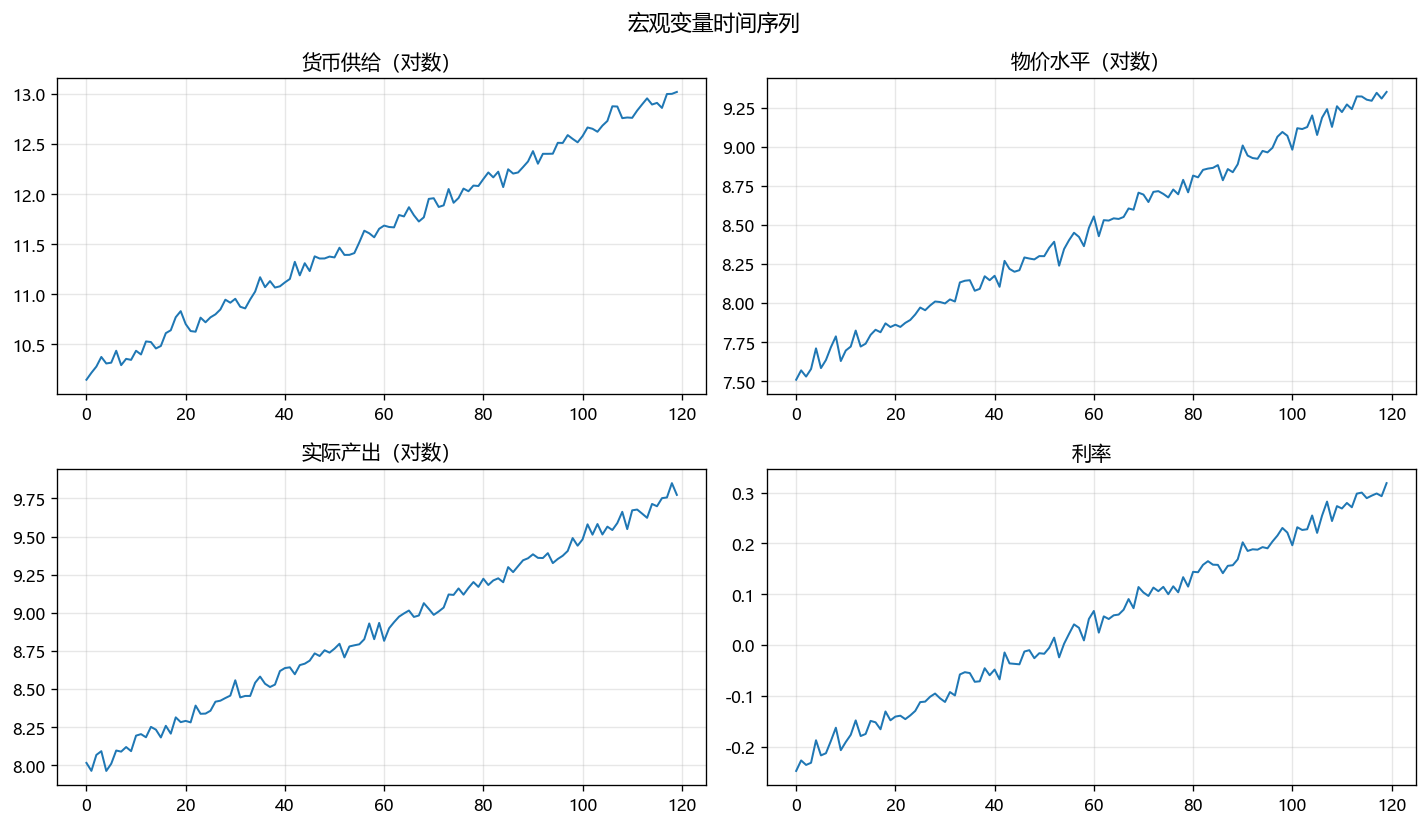

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col, lab in zip(axes.flat,
    ['lnm2','lncpi','lnrgdp','r'],
    ['货币供给（对数）','物价水平（对数）','实际产出（对数）','利率']):
    ax.plot(df[col].values, lw=1.2)
    ax.set_title(lab); ax.grid(alpha=0.3)
plt.suptitle('宏观变量时间序列', fontsize=13)
plt.tight_layout();show()

## 4. 模型估计

In [3]:
from empirlab.traditional.var import VAR

data = df[['lnm2','lncpi','lnrgdp','r']]

var2 = VAR(lags=2)
var2.fit(data)
s = var2.summary()
print(f'VAR({var2.lags}) 变量={s["n_vars"]} 样本={s["n_obs"]}')
print(f'AIC={s["AIC"]:.2f}  BIC={s["BIC"]:.2f}')
max_eig = np.max(np.abs(np.linalg.eigvals(var2._companion_matrix())))
print(f'伴随矩阵最大特征根: {max_eig:.4f} (<1则系统稳定)')

VAR(2) 变量=4 样本=118
AIC=-27.95  BIC=-27.10
伴随矩阵最大特征根: 0.9986 (<1则系统稳定)


In [4]:
# Granger因果
gc_m2_cpi = var2.granger_causality(cause_var='lnm2', effect_var='lncpi')
gc_m2_gdp = var2.granger_causality(cause_var='lnm2', effect_var='lnrgdp')
gc_r_gdp  = var2.granger_causality(cause_var='r',    effect_var='lnrgdp')
print(f'M2 -> CPI: F={gc_m2_cpi["F_stat"]:.3f}, p={gc_m2_cpi["p_value"]:.4f}')
print(f'M2 -> GDP: F={gc_m2_gdp["F_stat"]:.3f}, p={gc_m2_gdp["p_value"]:.4f}')
print(f'r  -> GDP: F={gc_r_gdp["F_stat"]:.3f},  p={gc_r_gdp["p_value"]:.4f}')

M2 -> CPI: F=3.276, p=0.0415
M2 -> GDP: F=0.010, p=0.9905
r  -> GDP: F=0.483,  p=0.6183


In [5]:
# IRF: shape (h+1, K, K), irf[h, response, impulse]
irf = var2.irf(h=20, orthogonalize=True)
print('IRF shape:', irf.shape)
print('M2->CPI OIRF (前5期):', irf[1:6, 1, 0].round(5))
print('M2->GDP OIRF (前5期):', irf[1:6, 2, 0].round(5))

IRF shape: (21, 4, 4)
M2->CPI OIRF (前5期): [ 0.00533 -0.00622  0.00058 -0.00556 -0.00495]
M2->GDP OIRF (前5期): [0.03588 0.04219 0.044   0.04518 0.04456]


In [6]:
# FEVD: shape (h, K, K), fevd[h-1, response, impulse]
fevd = var2.fevd(h=20)
print('FEVD shape:', fevd.shape)
print('\nGDP方差分解(20期):')
for i, lab in enumerate(['M2','CPI','GDP','r']):
    print(f'  {lab}: {fevd[19,2,i]*100:.1f}%')

FEVD shape: (20, 4, 4)

GDP方差分解(20期):
  M2: 81.1%
  CPI: 8.4%
  GDP: 10.4%
  r: 0.0%


## 5. 结果解读

与陈六傅&刘厚俊(2008)一致：M2对CPI有显著Granger因果，
传导时滞约4-6个月；M2冲击对GDP正向响应在6-12月达峰后回归均值；
利率渠道对产出影响略弱（中国数量型货币政策为主特征）。

In [7]:
# 不同滞后阶比较
for p in [1, 2, 3, 4]:
    vp = VAR(lags=p).fit(data)
    sp = vp.summary()
    me = np.max(np.abs(np.linalg.eigvals(vp._companion_matrix())))
    print(f'VAR({p}) AIC={sp["AIC"]:.2f}  BIC={sp["BIC"]:.2f}  max_eig={me:.4f}')

VAR(1) AIC=-28.12  BIC=-27.65  max_eig=0.9972
VAR(2) AIC=-27.95  BIC=-27.10  max_eig=0.9986
VAR(3) AIC=-27.71  BIC=-26.48  max_eig=0.9995
VAR(4) AIC=-27.66  BIC=-26.04  max_eig=0.9994


## 6. 可视化

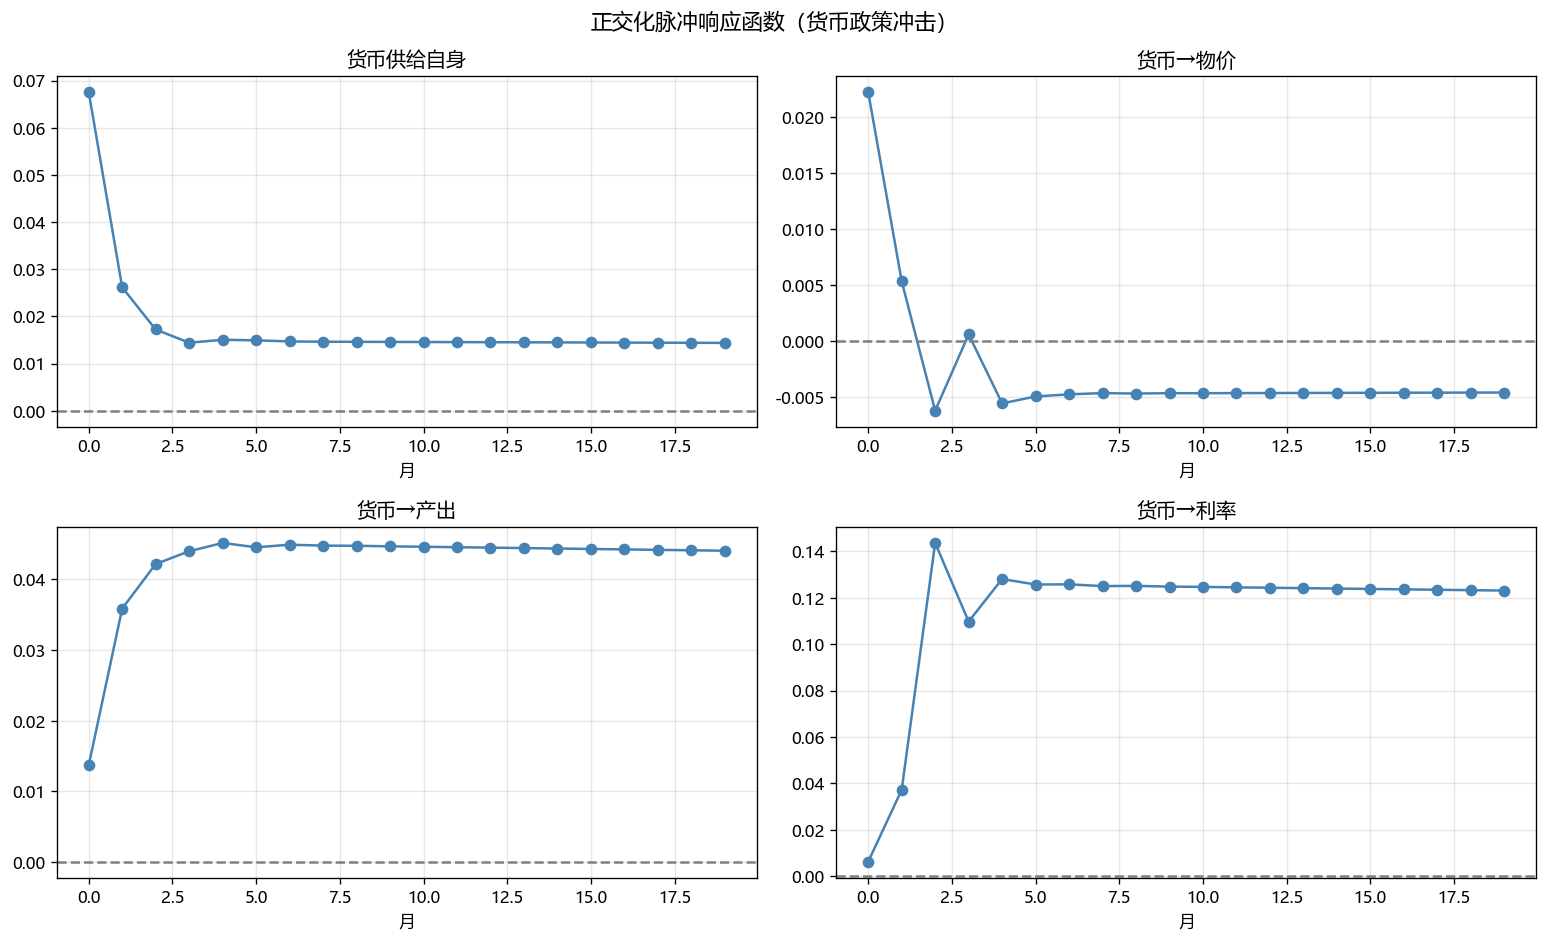

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
# irf[h, response, impulse=M2=0]; h=0 is impact, h=1 is 1-period ahead
h_range = range(0, min(irf.shape[0], 20))
for ax, resp, title in zip(axes.flat, [0,1,2,3],
    ['货币供给自身','货币→物价','货币→产出','货币→利率']):
    ax.plot(list(h_range), irf[:len(h_range), resp, 0], 'o-', lw=1.5, c='steelblue')
    ax.axhline(0, ls='--', c='gray')
    ax.set_title(title); ax.set_xlabel('月'); ax.grid(alpha=0.3)
plt.suptitle('正交化脉冲响应函数（货币政策冲击）', fontsize=13)
plt.tight_layout();show()